In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math
from IPython.display import Latex
from scipy.integrate import nquad

In [2]:
c=2.998*10**8 #in m/s
v0 = 220*1000/c
v_esc = 500*1000/c 
v_E = 240*1000/c 
#w_minus = 60*10**-3
#w_plus = 20*10**-3
ratio=v_esc/v0
N0 = v0**3*np.pi*(np.sqrt(np.pi)*scipy.special.erf(ratio)-2*ratio*np.exp(-ratio**2))
dm_density = 0.4e9
a0 = 2.68e-4 #eV^-1
target_density = 1.31e24 #GeV/cm^3
Z=14 #silicon
#dm_density = 0.4e9 #eV/cm^3, plus minus 0.1
Si_nucleus_mass = 28*938e6 #eV
w0=60e-3 #eV
proton_mass= 938.272e6 #eV
q0 = 56e3 #eV
ThomasFermi = 0.37 *a0

In [3]:
def reducedMass(m1, m2):
    return m1*m2/(m1+m2)

In [4]:
def inverseMeanFunction_sol1(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf((v_min+v_E)/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 4*np.exp(-v_esc**2/v0**2)*v_E
    return summ*const

def inverseMeanFunction_sol2(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf(v_esc/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 2*np.exp(-v_esc**2/v0**2)*(v_esc-v_min+v_E)
    return summ*const

def inverseMeanFunction(v_min, m_chi, const = v0**2*np.pi/(2*v_E*N0)):
    """
    Returns the inverse mean value for any given v_min.  
    Parameters:
        v_min: input velocity
        m_chi: mass of dark matter
        const: scaling value for graphing.  As a default, it gives the true scale of the equation
    """
    if v_min>v_esc+v_E:
        return 0
    elif v_min>v_esc-v_E:
        return inverseMeanFunction_sol2(v_min,m_chi, const)
    else: 
        return inverseMeanFunction_sol1(v_min,m_chi, const)

In [5]:
def v_min(q,m_chi, n): #q in eV
    return n*w0/q+q/(2*m_chi)

In [6]:
def R_over_q_one_n(q,n, m_chi, N_T, sigma): #q in keV
    q=q*1000
    reducedmass = reducedMass(m_chi, proton_mass) #in eV
    constants = N_T*dm_density/m_chi * Z**2*sigma/(2*reducedmass**2)
    inside_summation = (q/math.factorial(n)) 
    inside_summation*=(q/q0)**(2*n)*np.exp(-(q/q0)**2)*inverseMeanFunction(v_min(q,m_chi,n),m_chi)
    #inside_summation*=Screening(q)
    return constants*inside_summation *2.998e10 *3.15576e7 *1000 #convertion to [kg year keV]^-1

In [7]:
q_range = np.linspace(0,2.5,250)
q_range = 10**q_range

In [8]:
def Screening(q):
    return (ThomasFermi*q)**4/(1+(ThomasFermi*q)**2)**2

In [9]:
mX=40e6
NT = 6.022e23/(28.085e-3)
deriv = [[R_over_q_one_n(q,n,mX,NT, 1e-42) for q in q_range] for n in range(1,11)]

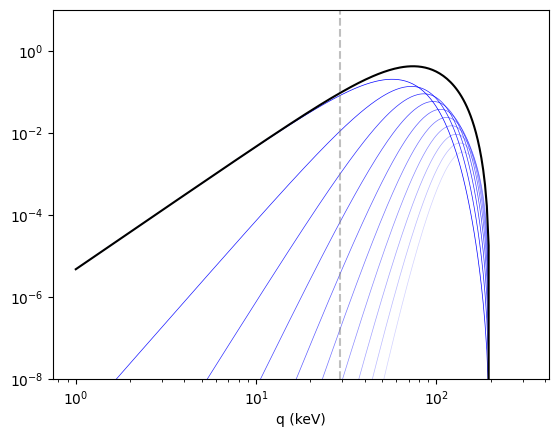

In [10]:
total = np.zeros(len(q_range))
for i in range(10):
    plt.plot(q_range, deriv[i], color="blue", alpha=(11-i)/11, linewidth=0.5)
    for point in range(len(q_range)):
        total[point]+=(deriv[i])[point]
plt.plot(q_range, total, color="black")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylim([1e-8,10])
plt.vlines(40e6*v0/1000, 10**-8, 10, color="grey", alpha=0.5, linestyle="dashed")
plt.show()

In [11]:
def R_over_q_one_n_Screened(q,n, m_chi, N_T, sigma): #q in keV
    return R_over_q_one_n(q,n, m_chi, N_T, sigma)*Screening(q*1000)

def scatteringRate_better(m_chi, n_min, N_T, top=10):
    root = m_chi**2*(v_esc+v_E)**2-2*w0*m_chi #change to n*w0
    if root<0:
        return 0
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root))/1000, 
          (m_chi*(v_esc+v_E)+np.sqrt(root))/1000]
    summ = np.sum([scipy.integrate.nquad(R_over_q_one_n_Screened,[[(m_chi*(v_esc+v_E)-np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w0*n*m_chi))/1000, 
          (m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w0*n*m_chi))/1000]],
                                         args=(n,m_chi, N_T, 1))[0] for n in np.arange(n_min,n_min+top)])
    return summ

def crossSection_better(m_chi, n_min, N_T, rate=3, topn=20):
    rate = scatteringRate_better(m_chi, n_min, N_T, top=topn)
    if rate==0:
        return None
    return 3/rate

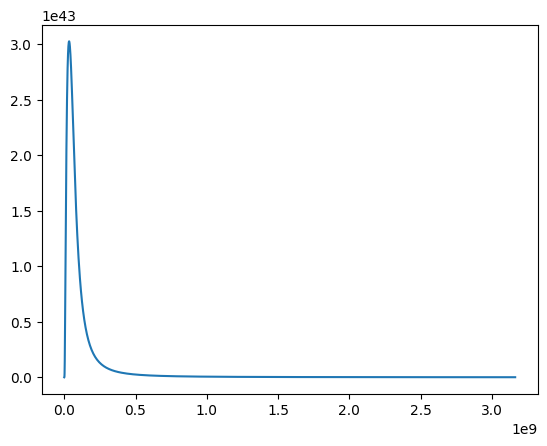

In [12]:
mass_range = 10**np.linspace(5.5, 9.5, 300) #in eV
SR1 = [scatteringRate_better(m,1,NT, 10) for m in mass_range]
plt.plot(mass_range, SR1)
plt.show()

/var/folders/ld/4n9y5rh93q58fgwgwnqf2w640000gn/T/ipykernel_79373/4249361183.py:10: RuntimeWarning: invalid value encountered in sqrt
  summ = np.sum([scipy.integrate.nquad(R_over_q_one_n_Screened,[[(m_chi*(v_esc+v_E)-np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w0*n*m_chi))/1000,
/var/folders/ld/4n9y5rh93q58fgwgwnqf2w640000gn/T/ipykernel_79373/4249361183.py:11: RuntimeWarning: invalid value encountered in sqrt
  (m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w0*n*m_chi))/1000]],
/var/folders/ld/4n9y5rh93q58fgwgwnqf2w640000gn/T/ipykernel_79373/2996260184.py:6: RuntimeWarning: overflow encountered in power
  inside_summation*=(q/q0)**(2*n)*np.exp(-(q/q0)**2)*inverseMeanFunction(v_min(q,m_chi,n),m_chi)
/var/folders/ld/4n9y5rh93q58fgwgwnqf2w640000gn/T/ipykernel_79373/2996260184.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  inside_summation*=(q/q0)**(2*n)*np.exp(-(q/q0)**2)*inverseMeanFunction(v_min(q,m_chi,n),m_chi)


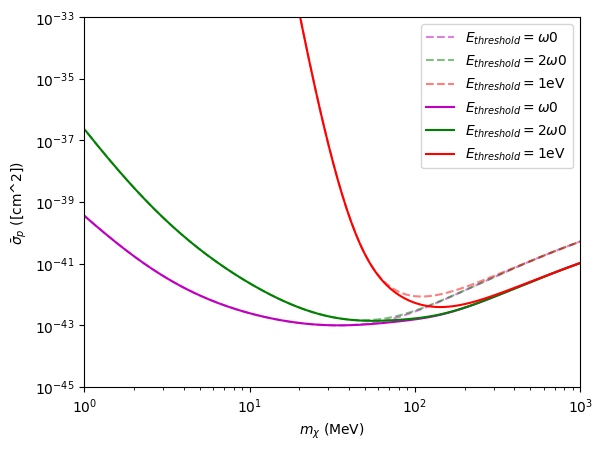

In [15]:
mass_range = 10**np.linspace(5.5, 9.5, 300) #in eV
cr1 = [crossSection_better(m, 1, NT, topn=10) for m in mass_range]
cr2 = [crossSection_better(m, 2, NT, topn=10) for m in mass_range]
cr3 = [crossSection_better(m, int(1/w0), NT, topn=10) for m in mass_range]

cr1_50 = [crossSection_better(m, 1, NT, topn=50) for m in mass_range]
cr2_50 = [crossSection_better(m, 2, NT, topn=50) for m in mass_range]
cr3_50 = [crossSection_better(m, int(1/w0), NT, topn=50) for m in mass_range]

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_\chi$ (MeV)')
plt.ylabel(r"$\bar{\sigma}_p$ ([cm^2])")
plt.ylim([1e-45, 1e-33])
plt.xlim([1, 1e3])

plt.plot(mass_range/1e6, cr1, color="m", label=r"$E_{threshold}=\omega0$", linestyle="dashed", alpha=0.5)
plt.plot(mass_range/1e6, cr2, color="g", label=r"$E_{threshold}=2\omega0$", linestyle="dashed", alpha=0.5)
plt.plot(mass_range/1e6, cr3, color="r", label=r"$E_{threshold}=$1eV", linestyle="dashed", alpha=0.5)

plt.plot(mass_range/1e6, cr1_50, color="m", label=r"$E_{threshold}=\omega0$")
plt.plot(mass_range/1e6, cr2_50, color="g", label=r"$E_{threshold}=2\omega0$")
plt.plot(mass_range/1e6, cr3_50, color="r", label=r"$E_{threshold}=$1eV")
plt.legend()

In [16]:
def R_over_q_combo(q,m_chi, N_T, sigma, n_min, top=10):
    arr = []
    for n in range(n_min, n_min+top):
        arr.append(R_over_q_one_n(q,n, m_chi, N_T, sigma))
        '''except OverflowError:
                print("n={0}\t q={1}".format(n, q))
                break'''
    return sum(arr)*Screening(q*1000)

def scatteringRate_sumfirst(m_chi, n_min, N_T, top=10):
    root = m_chi**2*(v_esc+v_E)**2-2*w0*m_chi #change to n*w0
    if root<0:
        return 0
    bounds = [(m_chi*(v_esc+v_E)-np.sqrt(root))/1000, 
          (m_chi*(v_esc+v_E)+np.sqrt(root))/1000]
    integral = scipy.integrate.nquad(R_over_q_combo,[bounds],
                                         args=(m_chi, N_T, 1, n_min, top))[0]
    return integral

def crossSect_sumfirst(m_chi, n_min, N_T, rate=3, topn=20):
    rate = scatteringRate_sumfirst(m_chi, n_min, N_T, top=topn)
    if rate==0:
        return None
    return 3/rate

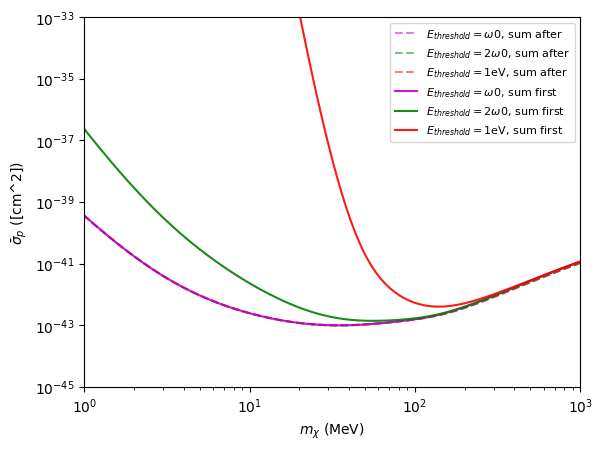

In [17]:
#beware of overflow error top above ~45
cr1_sumf = [crossSect_sumfirst(m, 1, NT, topn=45) for m in mass_range]
cr2_sumf = [crossSect_sumfirst(m, 2, NT, topn=45) for m in mass_range]

cr3_sumf = [crossSect_sumfirst(m, int(1/w0), NT, topn=45) for m in mass_range]

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_\chi$ (MeV)')
plt.ylabel(r"$\bar{\sigma}_p$ ([cm^2])")
plt.ylim([1e-45, 1e-33])
plt.xlim([1, 1e3])

plt.plot(mass_range/1e6, cr1_50, color="m", label=r"$E_{threshold}=\omega0$, sum after", linestyle="dashed", alpha=0.5)
plt.plot(mass_range/1e6, cr1_50, color="g", label=r"$E_{threshold}=2\omega0$, sum after", linestyle="dashed", alpha=0.5)
plt.plot(mass_range/1e6, cr1_50, color="r", label=r"$E_{threshold}=$1eV, sum after", linestyle="dashed", alpha=0.5)

plt.plot(mass_range/1e6, cr1_sumf, color="m", label=r"$E_{threshold}=\omega0$, sum first", alpha=0.9)
plt.plot(mass_range/1e6, cr2_sumf, color="g", label=r"$E_{threshold}=2\omega0$, sum first", alpha=0.9)
plt.plot(mass_range/1e6, cr3_sumf, color="r", label=r"$E_{threshold}=$1eV, sum first", alpha=0.9)

plt.legend(fontsize=8)
plt.show()